In [1]:
import pandas as pd

file_path = 'base_anonimizada/df_fam_pes.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE
0,1,953.0,2,11,205,0,2,1,2,1,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.00,0.5
1,2,873.0,2,11,205,0,3,1,2,1,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.00,0.0
2,3,1473.0,2,11,1302,0,2,1,1,2,...,1.0,0.0,0.0,0.0,0,0,0.0,0.0,0.00,0.0
3,4,751.0,2,11,122,0,2,1,1,1,...,1.0,0.0,0.0,0.0,0,0,0.5,0.0,0.00,0.0
4,5,1218.0,2,11,23,0,4,1,1,1,...,0.5,0.0,0.0,0.0,0,0,0.0,0.0,0.25,0.0


In [2]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [3]:
import numpy as np

# Definir condições
condicoes = [
    df['VL_RENDA_MEDIA_FAM'] <= 218,                      # 0 - pobreza
    (df['VL_RENDA_MEDIA_FAM'] > 218) & (df['VL_RENDA_MEDIA_FAM'] <= 706),  # 1 - baixa renda
    df['VL_RENDA_MEDIA_FAM'] > 706                       # 2 - acima de 1/2 salário mínimo
]

# Valores correspondentes
valores = [0, 1, 2]

# Criar a nova coluna
df['classe_renda'] = np.select(condicoes, valores)



In [4]:
df.groupby('classe_renda')['ID_FAM_ANON'].nunique()


classe_renda
0    1342624
1    2698399
2    5696752
Name: ID_FAM_ANON, dtype: int64

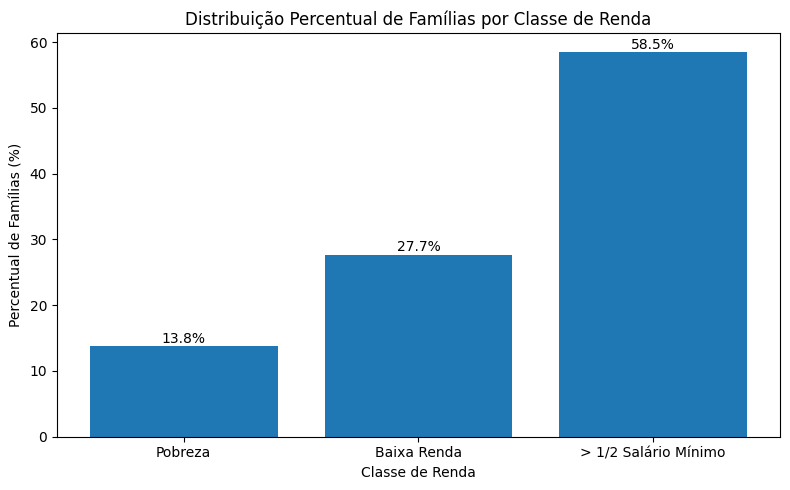

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Contar famílias únicas por classe de renda
familias_por_classe = (
    df.groupby('classe_renda')['ID_FAM_ANON']
      .nunique()
      .reset_index(name='qt_familias')
)

# 2) Calcular percentuais
total_familias = familias_por_classe['qt_familias'].sum()
familias_por_classe['percentual'] = (
    familias_por_classe['qt_familias'] / total_familias * 100
)

# 3) Criar gráfico
plt.figure(figsize=(8,5))
plt.bar(
    familias_por_classe['classe_renda'],
    familias_por_classe['percentual']
)

# Rótulos e formatação
plt.xlabel("Classe de Renda")
plt.ylabel("Percentual de Famílias (%)")
plt.title("Distribuição Percentual de Famílias por Classe de Renda")
plt.xticks([0,1,2], ["Pobreza", "Baixa Renda", "> 1/2 Salário Mínimo"])

# Mostrar valores no topo das barras
for i, v in enumerate(familias_por_classe['percentual']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()



In [6]:
# Variável-alvo binária para o modelo (triagem)
# 0 = até 1/2 salário mínimo (potencialmente elegível)
# 1 = acima de 1/2 salário mínimo (potencialmente não elegível)

df['y_bin'] = np.where(
    df['VL_RENDA_MEDIA_FAM'] > 706,
    1,
    0
)


In [7]:
df['classe_risco_qualificacao'] = np.where(
    df['y_bin'] == 1,
    'Potencialmente acima do limite',
    'Até 1/2 salário mínimo'
)


In [9]:
df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda,y_bin,classe_risco_qualificacao
0,1,953.0,2,11,205,0,2,1,2,1,...,0.0,0,0,0.0,0.0,0.00,0.5,2,1,Potencialmente acima do limite
1,2,873.0,2,11,205,0,3,1,2,1,...,0.0,0,0,0.0,0.0,0.00,0.0,2,1,Potencialmente acima do limite
2,3,1473.0,2,11,1302,0,2,1,1,2,...,0.0,0,0,0.0,0.0,0.00,0.0,2,1,Potencialmente acima do limite
3,4,751.0,2,11,122,0,2,1,1,1,...,0.0,0,0,0.5,0.0,0.00,0.0,2,1,Potencialmente acima do limite
4,5,1218.0,2,11,23,0,4,1,1,1,...,0.0,0,0,0.0,0.0,0.25,0.0,2,1,Potencialmente acima do limite


In [10]:
df.shape

(9737775, 54)

In [11]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [12]:
import pandas as pd
import numpy as np

# Tamanho total desejado para a amostra binária
N = 1_000_000
SEED = 42

# ------------------------------------------------------------
# 0) Checagens básicas
# ------------------------------------------------------------
cols_necessarias = ["classe_renda", "y_bin", "classe_risco_qualificacao"]
faltantes = [c for c in cols_necessarias if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltam colunas no df: {faltantes}")

# ------------------------------------------------------------
# 1) Distribuições na base original 
# ------------------------------------------------------------

print("\nDistribuição de classe_renda (0=pobreza, 1=baixa renda, 2=acima 1/2 SM):")
dist_classe = df["classe_renda"].value_counts(dropna=False).sort_index()
print(dist_classe)

print("\nDistribuição de y_bin (0=até 1/2 SM, 1=acima):")
dist_y = df["y_bin"].value_counts(dropna=False).sort_index()
print(dist_y)

print("\nDistribuição de classe_risco_qualificacao:")
dist_risco = df["classe_risco_qualificacao"].value_counts(dropna=False)
print(dist_risco)

print("\nCrosstab: classe_renda x y_bin (checar consistência dos cortes):")
print(pd.crosstab(df["classe_renda"], df["y_bin"], dropna=False))

print("\nCrosstab: classe_risco_qualificacao x y_bin:")
print(pd.crosstab(df["classe_risco_qualificacao"], df["y_bin"], dropna=False))

# percentuais gerais
print("\nPercentuais (base original):")
print("classe_renda (%):")
print((dist_classe / len(df) * 100).round(2))
print("\ny_bin (%):")
print((dist_y / len(df) * 100).round(2))

# ------------------------------------------------------------
# 2) Amostragem BALANCEADA por y_bin -> df_bal_binario
# ------------------------------------------------------------
n_por_classe = N // 2

vcb = df["y_bin"].dropna().value_counts().sort_index()
if (vcb < n_por_classe).any():
    raise ValueError(
        f"Alguma classe de y_bin não tem linhas suficientes para amostrar {n_por_classe} por classe.\n"
        f"Counts:\n{vcb}"
    )

amostras = []
for i, yval in enumerate(sorted(df["y_bin"].dropna().unique())):
    amostras.append(
        df[df["y_bin"] == yval].sample(n=n_por_classe, random_state=SEED + i)
    )

df_bal_binario = (
    pd.concat(amostras, axis=0)
      .sample(frac=1, random_state=SEED)
      .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3) Distribuições no df_bal_binario
# ------------------------------------------------------------
print("\n\n=== AMOSTRA FINAL (df_bal_binario - balanceada por y_bin) ===")

dist_y_bal = df_bal_binario["y_bin"].value_counts(dropna=False).sort_index()
dist_classe_bal = df_bal_binario["classe_renda"].value_counts(dropna=False).sort_index()
dist_risco_bal = df_bal_binario["classe_risco_qualificacao"].value_counts(dropna=False)

print("\nDistribuição de y_bin no df_bal_binario:")
print(dist_y_bal)

print("\nDistribuição de classe_renda (0/1/2) dentro do df_bal_binario:")
print(dist_classe_bal)

print("\nDistribuição de classe_risco_qualificacao no df_bal_binario:")
print(dist_risco_bal)

print("\nCrosstab: classe_renda x y_bin no df_bal_binario:")
print(pd.crosstab(df_bal_binario["classe_renda"], df_bal_binario["y_bin"], dropna=False))

print("\nCrosstab: classe_risco_qualificacao x y_bin no df_bal_binario:")
print(pd.crosstab(df_bal_binario["classe_risco_qualificacao"], df_bal_binario["y_bin"], dropna=False))

print("\nPercentuais (df_bal_binario):")
print("classe_renda (%):")
print((dist_classe_bal / len(df_bal_binario) * 100).round(2))
print("\ny_bin (%):")
print((dist_y_bal / len(df_bal_binario) * 100).round(2))

print("\nShape do df_bal_binario:")
print(df_bal_binario.shape)



Distribuição de classe_renda (0=pobreza, 1=baixa renda, 2=acima 1/2 SM):
classe_renda
0    1342624
1    2698399
2    5696752
Name: count, dtype: int64

Distribuição de y_bin (0=até 1/2 SM, 1=acima):
y_bin
0    4041023
1    5696752
Name: count, dtype: int64

Distribuição de classe_risco_qualificacao:
classe_risco_qualificacao
Potencialmente acima do limite    5696752
Até 1/2 salário mínimo            4041023
Name: count, dtype: int64

Crosstab: classe_renda x y_bin (checar consistência dos cortes):
y_bin               0        1
classe_renda                  
0             1342624        0
1             2698399        0
2                   0  5696752

Crosstab: classe_risco_qualificacao x y_bin:
y_bin                                 0        1
classe_risco_qualificacao                       
Até 1/2 salário mínimo          4041023        0
Potencialmente acima do limite        0  5696752

Percentuais (base original):
classe_renda (%):
classe_renda
0    13.79
1    27.71
2    58.50
Name:

In [13]:
df_bal_binario.to_csv("df_bal_binario.csv", index=False, encoding="utf-8")

In [14]:
import pandas as pd
import numpy as np

# Tamanho total desejado para a amostra
N = 1_000_000
SEED = 42  # reprodutível

# ------------------------------------------------------------
# 0) Checagens
# ------------------------------------------------------------
cols_necessarias = ["classe_renda", "y_bin", "classe_risco_qualificacao"]
faltantes = [c for c in cols_necessarias if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltam colunas no df: {faltantes}")

# ------------------------------------------------------------
# 1) Distribuições na base original 
# ------------------------------------------------------------

dist_classe = df["classe_renda"].value_counts(dropna=False).sort_index()
dist_y = df["y_bin"].value_counts(dropna=False).sort_index()
dist_risco = df["classe_risco_qualificacao"].value_counts(dropna=False)

print("\nDistribuição de classe_renda (0/1/2):")
print(dist_classe)

print("\nDistribuição de y_bin (0/1):")
print(dist_y)

print("\nDistribuição de classe_risco_qualificacao:")
print(dist_risco)

print("\nCrosstab: classe_renda x y_bin (base original):")
print(pd.crosstab(df["classe_renda"], df["y_bin"], dropna=False))

# ------------------------------------------------------------
# 2) AMOSTRA PROPORCIONAL À DISTRIBUIÇÃO ORIGINAL DE y_bin
# ------------------------------------------------------------
vc = df["y_bin"].value_counts().sort_index()
proporcoes = vc / vc.sum()

# Número de casos por classe (aprox), garantindo soma = N
n_por_classe_prop = (proporcoes * N).round().astype(int)

# Ajuste fino para garantir soma exatamente N (por arredondamento)
diferenca = N - n_por_classe_prop.sum()
if diferenca != 0:
    ordem_ajuste = vc.sort_values(ascending=False).index.tolist()
    idx = 0
    passo = 1 if diferenca > 0 else -1
    for _ in range(abs(diferenca)):
        classe_ajustar = ordem_ajuste[idx % len(ordem_ajuste)]
        n_por_classe_prop[classe_ajustar] += passo
        idx += 1

print("\nTamanho por classe (y_bin) na amostra proporcional:")
print(n_por_classe_prop, " (soma:", int(n_por_classe_prop.sum()), ")")

# Verificar se há linhas suficientes para cada classe binária
vc_disp = df["y_bin"].value_counts().sort_index()
if (vc_disp < n_por_classe_prop).any():
    faltam = (n_por_classe_prop - vc_disp)[(n_por_classe_prop - vc_disp) > 0]
    raise ValueError(
        "Alguma classe de y_bin não tem linhas suficientes para a amostragem proporcional.\n"
        f"Faltando:\n{faltam}\n"
        f"Disponível:\n{vc_disp}\n"
        f"Solicitado:\n{n_por_classe_prop}"
    )

# Amostragem proporcional por y_bin
amostras_prop = []
for i, (yval, n_cls) in enumerate(n_por_classe_prop.items()):
    amostra_classe = df[df["y_bin"] == yval].sample(
        n=int(n_cls),
        random_state=SEED + 100 + i
    )
    amostras_prop.append(amostra_classe)

df_prop_binario = (
    pd.concat(amostras_prop, axis=0)
      .sample(frac=1, random_state=SEED + 999)
      .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3) Distribuições na amostra proporcional binária
# ------------------------------------------------------------
print("\n=== AMOSTRA FINAL (df_prop_binario - proporcional por y_bin) ===")

dist_y_prop = df_prop_binario["y_bin"].value_counts(dropna=False).sort_index()
dist_classe_prop = df_prop_binario["classe_renda"].value_counts(dropna=False).sort_index()
dist_risco_prop = df_prop_binario["classe_risco_qualificacao"].value_counts(dropna=False)

print("\nDistribuição de y_bin no df_prop_binario:")
print(dist_y_prop)

print("\nDistribuição de classe_renda (0/1/2) dentro do df_prop_binario:")
print(dist_classe_prop)

print("\nDistribuição de classe_risco_qualificacao no df_prop_binario:")
print(dist_risco_prop)

print("\nCrosstab: classe_renda x y_bin no df_prop_binario:")
print(pd.crosstab(df_prop_binario["classe_renda"], df_prop_binario["y_bin"], dropna=False))

print("\nShape do df_prop_binario:")
print(df_prop_binario.shape)




Distribuição de classe_renda (0/1/2):
classe_renda
0    1342624
1    2698399
2    5696752
Name: count, dtype: int64

Distribuição de y_bin (0/1):
y_bin
0    4041023
1    5696752
Name: count, dtype: int64

Distribuição de classe_risco_qualificacao:
classe_risco_qualificacao
Potencialmente acima do limite    5696752
Até 1/2 salário mínimo            4041023
Name: count, dtype: int64

Crosstab: classe_renda x y_bin (base original):
y_bin               0        1
classe_renda                  
0             1342624        0
1             2698399        0
2                   0  5696752

Tamanho por classe (y_bin) na amostra proporcional:
y_bin
0    414984
1    585016
Name: count, dtype: int64  (soma: 1000000 )

=== AMOSTRA FINAL (df_prop_binario - proporcional por y_bin) ===

Distribuição de y_bin no df_prop_binario:
y_bin
0    414984
1    585016
Name: count, dtype: int64

Distribuição de classe_renda (0/1/2) dentro do df_prop_binario:
classe_renda
0    137592
1    277392
2    585016
Name:

In [15]:
# Salvar amostra proporcional
df_prop_binario.to_csv("df_prop_binario.csv", index=False, encoding="utf-8")